In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv("loan approval data.csv")

In [7]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [9]:
df.isna().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [10]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [11]:
## This is a binary classification problem

In [12]:
## Handle missing values:

categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["float64"]).columns

In [13]:
categotical_cols

NameError: name 'categotical_cols' is not defined

In [ ]:
numerical_cols

In [ ]:
# to fill null values, we can use imputer from sklearn:
from sklearn.impute import SimpleImputer

In [ ]:
numerical_imputer = SimpleImputer(strategy="mean")
numerical_cols = numerical_imputer.fit_transform(df[numerical_cols])

In [ ]:
categorical_imputer =  SimpleImputer(strategy="most_frequent")
categorical_cols = categorical_imputer.fit_transform(df[categorical_cols])

In [ ]:
df.isna().sum()

## EDA - Exploratory Data Analysis:

In [ ]:
# How balanced our classes are:

classe_count= df["Loan_Approved"].value_counts()
plt.pie(classe_count, labels=["No","Yes"], autopct="%1.1f%%")
plt.title("Loan approved or not")

In [ ]:
# Analyse Categories
#for gender

gender_vals=df["Gender"].value_counts()
ax = sns.barplot(gender_vals)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

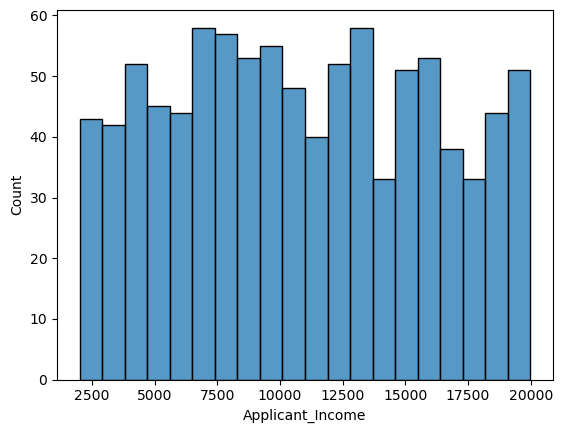

In [14]:
# Analyse income:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

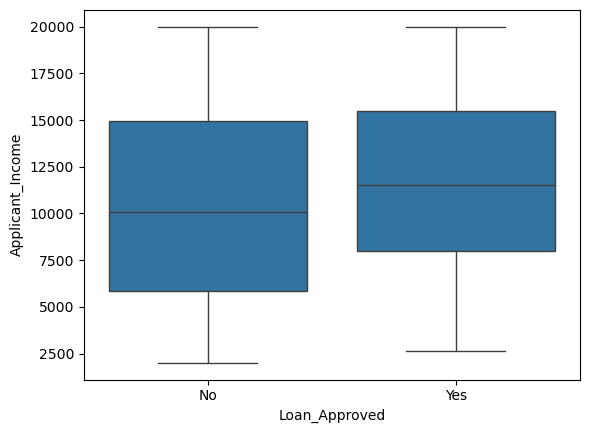

In [15]:
# checking outliers using box plots:
sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
    
)
#No Outliers:

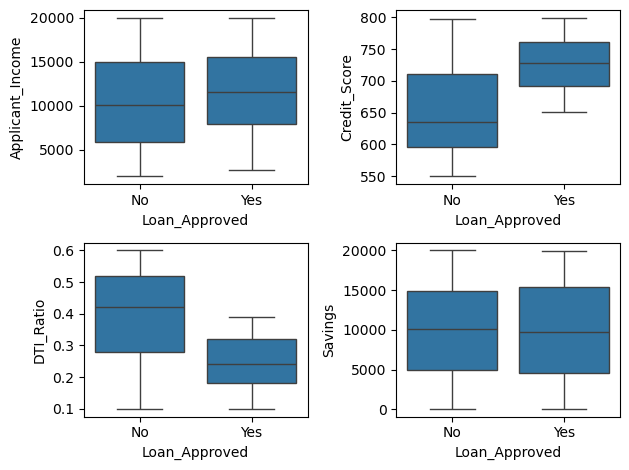

In [16]:
fig,axes = plt.subplots(2,2)

sns.boxplot(ax=axes[0,0], data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1], data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0], data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1], data=df,x="Loan_Approved",y="Savings")

plt.tight_layout()
#No outliers here

# Encoding:
## 1. label encoding - can done with use of maps OR Label Encoder of sklearn
## 2. One Hot Encoding - can done by using pandas GetDummies feature OR OneHotEncoder of sklearn

In [25]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [26]:
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [27]:
### OnehotEncoding

In [32]:
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe=OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

#encoder gives 2D array of encoded values instead of data frames

encoded_vals = ohe.fit_transform(df[cols])
#Converting that array in df:
encoded_df = pd.DataFrame(encoded_vals, columns =ohe.get_feature_names_out(cols), index=df.index)
encoded_df

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Employment_Status_nan,Marital_Status_Single,Marital_Status_nan,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,...,Property_Area_Semiurban,Property_Area_Urban,Property_Area_nan,Gender_Male,Gender_nan,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Employer_Category_nan
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
996,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
997,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
998,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [33]:
df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [34]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Property_Area_Semiurban,Property_Area_Urban,Property_Area_nan,Gender_Male,Gender_nan,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Employer_Category_nan
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


# Correlation Heatmap:

In [37]:
numerical_cols=df.select_dtypes(include="number")
corr_matrix = numerical_cols.corr()

In [38]:
corr_matrix

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Property_Area_Semiurban,Property_Area_Urban,Property_Area_nan,Gender_Male,Gender_nan,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Employer_Category_nan
Applicant_ID,1.000000,0.022070,0.043041,0.015179,0.013038,-0.029869,0.026255,0.000182,0.023798,0.033568,...,0.013182,-0.030453,-0.001314,0.036746,-0.001005,0.006070,-0.075704,0.015454,0.039444,0.019402
Applicant_Income,0.022070,1.000000,0.007860,-0.025458,-0.028181,-0.010352,-0.010993,-0.009625,-0.029615,0.019734,...,0.005031,-0.012199,-0.058237,-0.022989,0.004469,-0.025557,0.105836,-0.046846,-0.012141,-0.000036
Coapplicant_Income,0.043041,0.007860,1.000000,0.015098,-0.028062,0.060981,0.013156,0.061397,-0.015872,0.010070,...,-0.010468,0.052011,-0.047246,0.010724,-0.047766,-0.001173,0.038712,-0.004863,-0.048740,0.020718
Age,0.015179,-0.025458,0.015098,1.000000,-0.019788,-0.004425,0.024691,0.008359,-0.001037,0.039301,...,0.003165,-0.034233,0.017855,0.048610,0.000168,-0.068697,0.021770,-0.016579,0.073002,0.006529
Dependents,0.013038,-0.028181,-0.028062,-0.019788,1.000000,-0.007976,-0.027991,0.011970,-0.005253,0.024134,...,-0.033520,0.016697,0.018330,0.035691,-0.049718,-0.009381,-0.019351,0.040217,-0.056425,-0.018954
Credit_Score,-0.029869,-0.010352,0.060981,-0.004425,-0.007976,1.000000,-0.007444,0.002449,-0.069286,0.008280,...,-0.007150,-0.004053,0.020043,-0.049799,0.022356,-0.007259,0.069063,0.012313,-0.048025,-0.027074
Existing_Loans,0.026255,-0.010993,0.013156,0.024691,-0.027991,-0.007444,1.000000,0.049748,0.036499,-0.052752,...,-0.054971,0.055556,-0.043170,-0.036528,-0.005557,-0.009815,0.031486,-0.029996,0.047300,0.021845
DTI_Ratio,0.000182,-0.009625,0.061397,0.008359,0.011970,0.002449,0.049748,1.000000,0.004902,-0.010031,...,0.046420,0.002827,-0.020648,0.005504,0.009726,-0.007414,0.002123,0.006472,0.026212,-0.023598
Savings,0.023798,-0.029615,-0.015872,-0.001037,-0.005253,-0.069286,0.036499,0.004902,1.000000,0.016258,...,0.005586,0.044871,-0.064076,0.006320,-0.029420,-0.012079,0.004465,-0.018468,0.027770,-0.028833
Collateral_Value,0.033568,0.019734,0.010070,0.039301,0.024134,0.008280,-0.052752,-0.010031,0.016258,1.000000,...,0.020607,0.008409,-0.000478,-0.008867,0.022752,0.036611,-0.013848,-0.026135,-0.009913,0.024370


In [39]:
numerical_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.404817
Applicant_Income                   0.099770
Employer_Category_MNC              0.062015
Marital_Status_Single              0.053416
Collateral_Value                   0.040321
Employment_Status_nan              0.040155
Loan_Purpose_nan                   0.040155
Employer_Category_Private          0.035304
Gender_nan                         0.032282
Loan_Purpose_Personal              0.027617
Coapplicant_Income                 0.026428
Dependents                         0.022332
Applicant_ID                       0.021234
Loan_Purpose_Education             0.013201
Property_Area_Urban                0.010779
Property_Area_nan                  0.008661
Loan_Purpose_Home                  0.006036
Employment_Status_Self-employed   -0.001939
Marital_Status_nan                -0.007086
Property_Area_Semiurban           -0.014122
Education_Level                   -0.019102
Gender_Male                     

<Axes: >

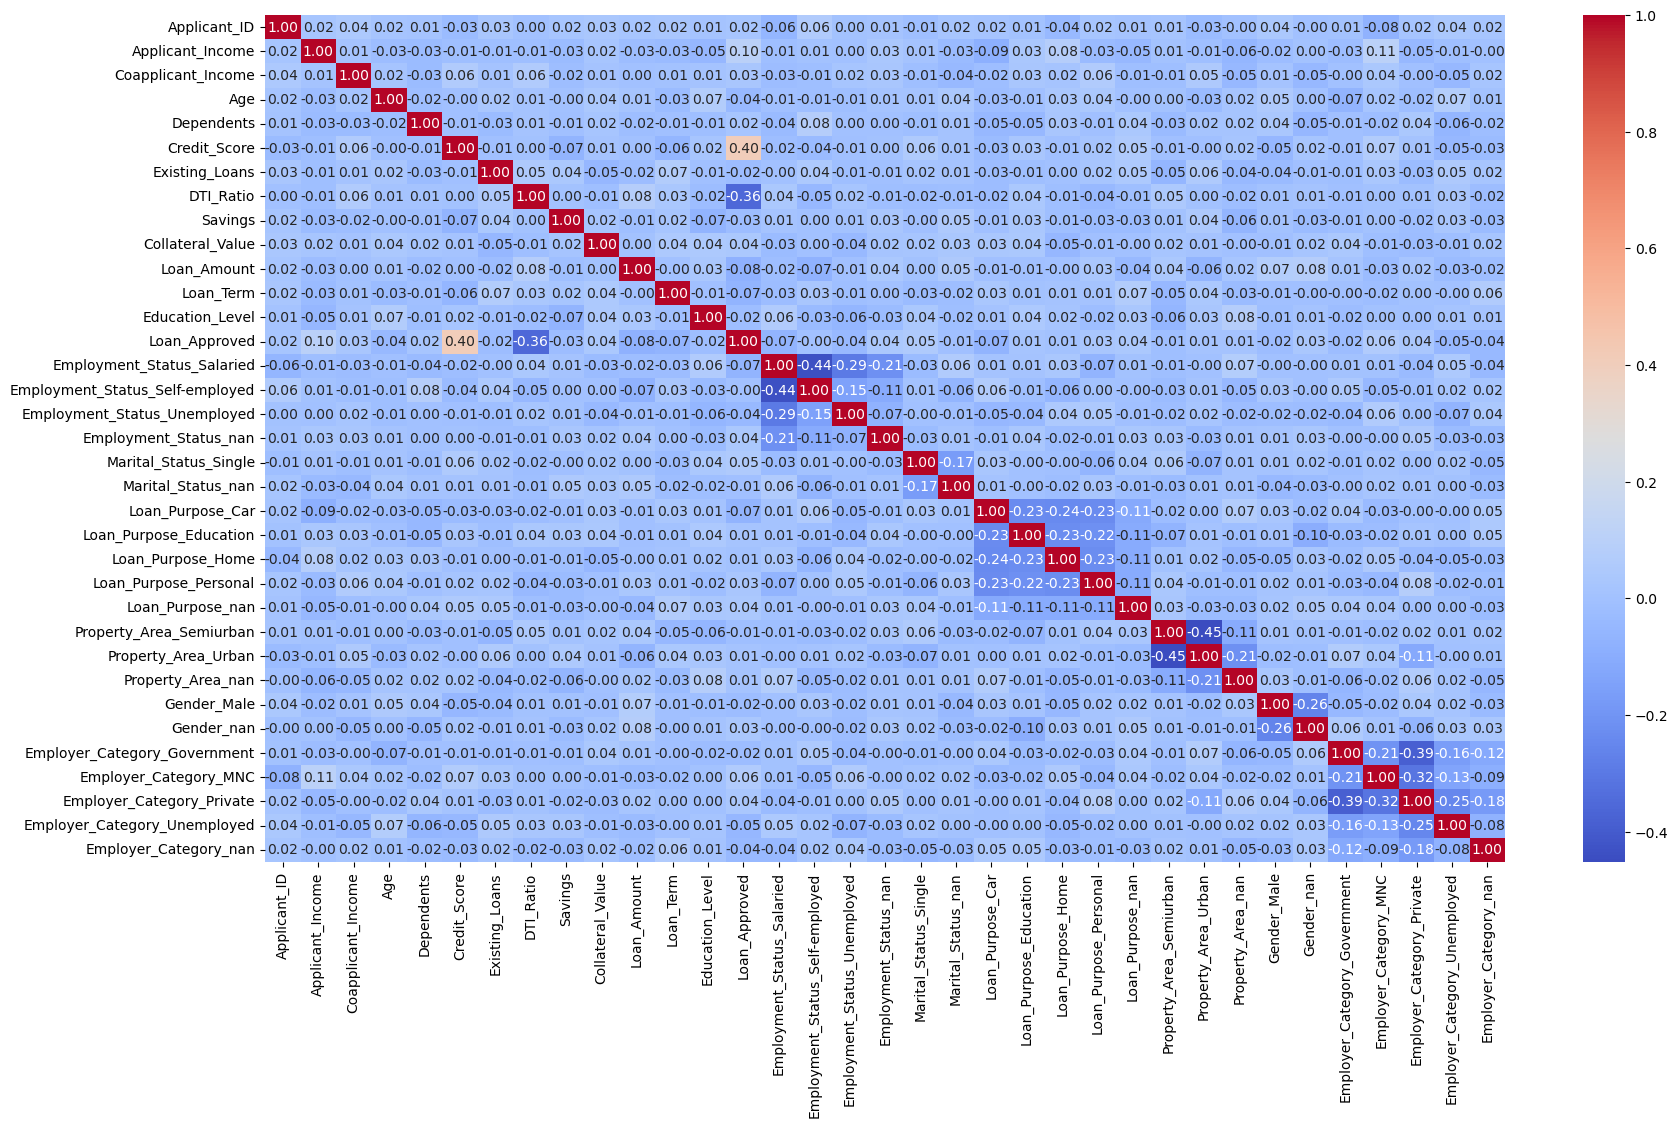

In [45]:
plt.figure(figsize=(20, 11))  # to control the size of figure
sns.heatmap(
    corr_matrix,
    annot=True,  #for annotations
    fmt=".2f",
    cmap="coolwarm"
)